In [1]:
from textblob import TextBlob

In [2]:
from textblob import TextBlob

text = TextBlob("I love this dress")

print(text.sentiment)

Sentiment(polarity=0.5, subjectivity=0.6)


In [3]:
import pandas as pd

In [4]:
import zipfile

In [5]:
zip_path = r"C:\Users\Vedika Pingat\Downloads\archive (11).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
import os

os.listdir("dataset")

['Women_s_E-Commerce_Clothing_Reviews_1594_1.csv']

In [13]:
import pandas as pd

df = pd.read_csv(
    r"dataset/Women_s_E-Commerce_Clothing_Reviews_1594_1.csv",
    sep=';',
    engine='python',
    quotechar='"'
)

In [14]:
df.head()

,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [15]:
df.columns

Index(['Unnamed: 0', 'Clothing.ID', 'Age', 'Title', 'Review.Text', 'Rating',
       'Recommended.IND', 'Positive.Feedback.Count', 'Division.Name',
       'Department.Name', 'Class.Name'],
      dtype='object')

In [16]:

df = df[['Review.Text']].copy()

In [17]:
df['Review.Text'] = df['Review.Text'].fillna('')

In [18]:
from textblob import TextBlob

In [19]:
TextBlob(df['Review.Text'].iloc[0]).sentiment

Sentiment(polarity=0.6333333333333333, subjectivity=0.9333333333333332)

In [20]:
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [21]:
df['Sentiment'] = df['Review.Text'].apply(get_sentiment)

In [22]:
df.head()

,Review.Text,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,Positive
1,Love this dress! it's sooo pretty. i happene...,Positive
2,I had such high hopes for this dress and reall...,Positive
3,"I love, love, love this jumpsuit. it's fun, fl...",Positive
4,This shirt is very flattering to all due to th...,Positive


In [23]:
df['Sentiment'].value_counts()

Sentiment
Positive    21227
Negative     1322
Neutral       937
Name: count, dtype: int64

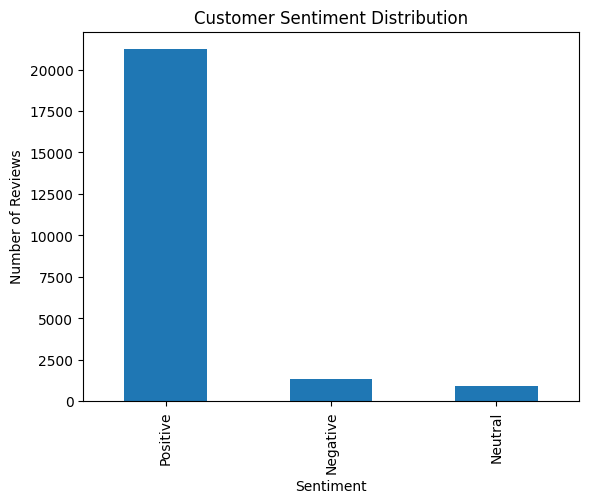

In [24]:
import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()